In [1]:
import pandas as pd
import numpy as np 
from sklearn import linear_model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import seaborn as sns
from sklearn.multiclass import OneVsOneClassifier
from sklearn.metrics import accuracy_score

In [2]:
loc = 'C:/Users/LAPTOP/Downloads/Obesity_level_prediction_dataset.csv'
drug_data = pd.read_csv(loc)
drug_data.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


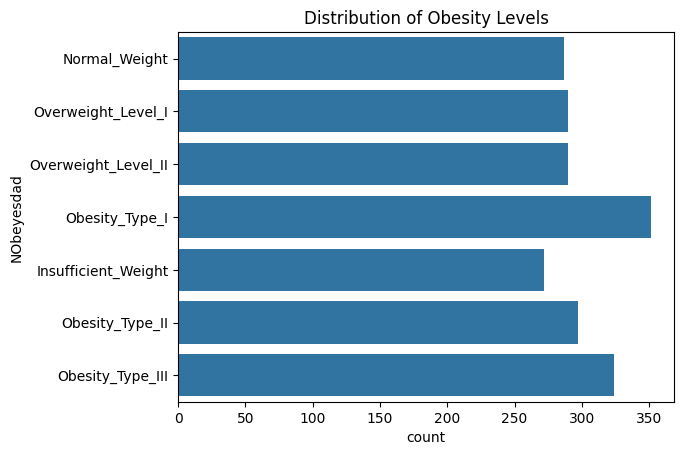

In [3]:
sns.countplot(y= 'NObeyesdad', data = drug_data)
plt.title('Distribution of Obesity Levels')
plt.show()

In [4]:
cont_columns = drug_data.select_dtypes(include=['float64']).columns.tolist()

scaler = StandardScaler()
scaled_feat = scaler.fit_transform(drug_data[cont_columns])

scaled_df = pd.DataFrame(scaled_feat, columns=scaler.get_feature_names_out(cont_columns))

scaled_data = pd.concat([drug_data.drop(columns=cont_columns), scaled_df], axis=1)

In [5]:
cat_columns = scaled_data.select_dtypes(include=['object']).columns.tolist() 
cat_columns.remove('NObeyesdad')

encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_feat = encoder.fit_transform(scaled_data[cat_columns])

encoded_df = pd.DataFrame(encoded_feat, columns=encoder.get_feature_names_out(cat_columns))

prepped_data = pd.concat([scaled_data.drop(columns=cat_columns), encoded_df], axis=1)

In [6]:
prepped_data

,NObeyesdad,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,Normal_Weight,-0.522124,-0.875589,-0.862558,-0.785019,0.404153,-0.013073,-1.188039,0.561997,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,Normal_Weight,-0.522124,-1.947599,-1.168077,1.088342,0.404153,1.618759,2.339750,-1.080625,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,Normal_Weight,-0.206889,1.054029,-0.366090,-0.785019,0.404153,-0.013073,1.163820,0.561997,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,Overweight_Level_I,0.423582,1.054029,0.015808,1.088342,0.404153,-0.013073,1.163820,-1.080625,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,Overweight_Level_II,-0.364507,0.839627,0.122740,-0.785019,-2.167023,-0.013073,-1.188039,-1.080625,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Obesity_Type_III,-0.525774,0.097045,1.711763,1.088342,0.404153,-0.456705,0.783135,0.407996,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2107,Obesity_Type_III,-0.367195,0.502844,1.800914,1.088342,0.404153,-0.004702,0.389341,-0.096251,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2108,Obesity_Type_III,-0.281909,0.541672,1.798868,1.088342,0.404153,0.075361,0.474971,-0.019018,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2109,Obesity_Type_III,0.007776,0.404927,1.785780,1.088342,0.404153,1.377801,0.151471,-0.117991,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [7]:
prepped_data['NObeyesdad'] = prepped_data['NObeyesdad'].astype('category').cat.codes
prepped_data.sample(5)

,NObeyesdad,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
611,0,-0.331453,-1.155952,-1.624436,1.088342,0.395424,1.133750,1.125290,-1.080625,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
332,1,0.423582,1.590034,-0.442470,-0.785019,-2.167023,-0.013073,-0.012109,-1.080625,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1603,3,-0.010808,-0.850965,0.511610,0.979554,1.676231,-1.621839,1.115247,0.048418,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1445,2,-0.573018,0.853037,0.624972,-0.785019,0.404153,-0.636125,-0.515821,-1.080625,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
334,5,-0.994977,-2.698006,-1.282647,-0.785019,0.404153,-0.013073,-0.012109,2.204618,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [8]:
ind_data = prepped_data.drop('NObeyesdad', axis=1)
dep_data = prepped_data['NObeyesdad']

In [45]:
x_train, x_test, y_train, y_test = train_test_split(ind_data, dep_data, test_size=0.2, random_state=44, stratify=dep_data)

In [46]:
model_ova = LogisticRegression(multi_class='ovr', max_iter=1000)
model_ova.fit(x_train, y_train)

C:\Users\LAPTOP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='ovr')

In [47]:
y_pred_ova = model_ova.predict(x_test)
print('One Vs All Strategy')
print(f'Accuracy: {np.round(100*accuracy_score(y_test, y_pred_ova),2)}%')

One Vs All Strategy
Accuracy: 81.09%


In [48]:
model_ovo = OneVsOneClassifier(LogisticRegression(max_iter=1000))
model_ovo.fit(x_train, y_train)
y_pred_ovo = model_ovo.predict(x_test)
print('One Vs One Strategy')
print(f'Accuracy: {np.round(100*accuracy_score(y_test, y_pred_ovo), 2)}%')

One Vs One Strategy
Accuracy: 93.62%


In [83]:
def Obesity_risk_pipeline(data_path, test_size):
    obs_df = pd.read_csv(data_path)
    #print("Columns in data:", obs_df.columns.tolist())
    fl_columns = obs_df.select_dtypes(include=['float64']).columns.tolist()
    s_scaler = StandardScaler()
    s_feat = s_scaler.fit_transform(obs_df[fl_columns])
    s_df = pd.DataFrame(s_feat, columns=s_scaler.get_feature_names_out(fl_columns))
    s_data = pd.concat([obs_df.drop(columns=fl_columns), s_df], axis=1)
    cl_columns = s_data.select_dtypes(include=['object']).columns.tolist()
    cl_columns.remove('NObeyesdad')
    enc = OneHotEncoder(sparse_output=False, drop='first')
    pol_feat = enc.fit_transform(s_data[cl_columns])
    pol_df = pd.DataFrame(pol_feat, columns=enc.get_feature_names_out(cl_columns))
    pol_data = pd.concat([s_data.drop(columns=cl_columns), pol_df], axis=1)
    pol_data['NObeyesdad'] = pol_data['NObeyesdad'].astype('category').cat.codes
    x = pol_data.drop('NObeyesdad', axis=1)
    y = pol_data['NObeyesdad']
    train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=test_size, random_state=44, stratify=y)
    OneforOne = OneVsOneClassifier(LogisticRegression(max_iter=1000))
    OneforOne.fit(train_x, train_y)
    pred_y = OneforOne.predict(test_x)
    print(f'Acuracy: {np.round(100*accuracy_score(pred_y, test_y),2)}%')

Obesity_risk_pipeline(loc, .2)

Acuracy: 93.62%
